## makes aral sea balance

In [21]:
# setup imports
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from ewatercycle.observation.grdc import get_grdc_data
from tqdm import tqdm

import src.aral as aral
from src.constants import PARAMETER_NAMES
from src.paths import *

In [2]:
### generate forcing
experiment_start_date = "1940-01-01T00:00:00Z"
experiment_end_date = "2020-12-31T00:00:00Z"

shapefile_kerki = "Kerki_GRDC"
shapefile_TA = "Tyumen_Aryk_GRDC"
shapefile_Aral = "AralSea"

# ERA5_forcing_kerki = generate_lumped_ERA5_forcing(shapefile_kerki, experiment_start_date, experiment_end_date)
# ERA5_forcing_TA = generate_lumped_ERA5_forcing(shapefile_TA, experiment_start_date, experiment_end_date)
# ERA5_forcing_Aral = generate_lumped_ERA5_forcing(shapefile_Aral, experiment_start_date, experiment_end_date)

In [3]:
Syr_kaza = aral.load_grdc_monthly(2316201, name="Syr Darya Kazalinsk")
Amu_chatly = aral.load_grdc_monthly(2817100, name="Amu Darya Chatly")

In [4]:
### imports

# Parameters HBV model after calibration with CMA-ES:

parameter_set = [
    8.507048,  # Imax
    0.566942,  # Ce
    448.172323,  # Sumax
    0.714943,  # Beta
    0.045901,  # Pmax
    2.377915,  # Tlag
    0.011572,  # Kf
    0.004388,  # Ks
    0.422621,  # FM
]

# Initial conditions placeholder
initial_conditions = np.array(
    [
        0,  # Si
        100,  # Su
        0,  # Sf
        5,  # Ss
        0,  # Sp
    ]
)

# kerki simulation
# simulatie_kerki = simulate_HBV(ERA5_forcing_kerki, parameter_set=parameter_set, initial_conditions=initial_conditions)
# kerki_hbv_m3 = mmday_to_m3s(simulatie_kerki, shapefile_kerki)
# saved_files  = save_HBV_results(simulatie_kerki,shape_name=shapefile_kerki, forcing_type="ERA5" )
# print(saved_files)
# simulatie_TA = simulate_HBV(ERA5_forcing_TA, parameter_set  )
# save_HBV_results(simulatie_kerki,shape_name=shapefile_kerki, forcing_type="ERA5" )
# simulatie_Aral = simulate_HBV(ERA5_forcing_Aral, parameter_set  )

In [5]:
# forcing_TA = load_lumped_forcing_data(shape_name=shapefile_TA, forcing_type="ERA5", year_span="1940-2020")
# simulatie_TA = simulate_HBV(forcing_TA, parameter_set=TYUMEN_ARYK_HBV_PARAMS_CMAES, initial_conditions=initial_conditions)
# save_HBV_results(simulatie_TA,shape_name=shapefile_TA, forcing_type="ERA5" )

In [6]:
path_to_kerki = OUTPUT_HBV / "Kerki_GRDC" / "ERA5" / "Kerki_GRDC_ERA5_1940-2020.pkl"
path_to_TA = OUTPUT_HBV / "Tyumen_Aryk_GRDC" / "ERA5" / "Tyumen_Aryk_GRDC_ERA5_1940-2020.pkl"
# Read the pickle
df_kerki = pd.read_pickle(path_to_kerki)
df_TA = pd.read_pickle(path_to_TA)


# test
df_kerki = df_kerki
df_TA = df_TA

In [7]:
path_to_kerki_params = RUNS_HBV / "cmaes_dask_test" / "best_params_df_kerki.pkl"
path_to_TA_params = RUNS_HBV / "cmaes_dask_TA" / "best_params_df_TA.pkl"

best_params_df_kerki = pd.read_pickle(path_to_kerki_params)
best_params_df_TA = pd.read_pickle(path_to_TA_params)

parameter_sets_TA = best_params_df_TA[PARAMETER_NAMES].to_numpy().tolist()
parameter_sets_kerki = best_params_df_kerki[PARAMETER_NAMES].to_numpy().tolist()

In [8]:
# forcing_TA = load_lumped_forcing_data(
#     shape_name=shapefile_TA,
#     forcing_type="ERA5",
#     year_span="1940-2020"
# )

# for i, parameter_set in enumerate(parameter_sets_TA):
#     simulatie_TA = simulate_HBV(
#         forcing_TA,
#         parameter_set=parameter_set,
#         initial_conditions=initial_conditions
#     )

#     parameters = dict(zip(PARAMETER_NAMES, parameter_set))

#     save_HBV_results(
#         simulatie_TA,
#         shape_name=shapefile_TA,
#         forcing_type="ERA5",
#         run_tag=f"cmaes_{i:03d}",
#         parameters=parameters
#     )

In [9]:
# forcing_kerki = load_lumped_forcing_data(
#     shape_name=shapefile_kerki,
#     forcing_type="ERA5",
#     year_span="1940-2020"
# )

# for i, parameter_set in enumerate(parameter_sets_kerki):
#     simulatie_kerki = simulate_HBV(
#         forcing_kerki,
#         parameter_set=parameter_set,
#         initial_conditions=initial_conditions,
#         leave_pbar = False,
#         delete_files=True,
#     )

#     parameters = dict(zip(PARAMETER_NAMES, parameter_set))

#     save_HBV_results(
#         simulatie_kerki,
#         shape_name=shapefile_kerki,
#         forcing_type="ERA5",
#         run_tag=f"cmaes_{i:03d}",
#         parameters=parameters
#     )

In [14]:
# Tyumen Aryk / Syr Darya
output_dir_TA = RUNS_HBV / "Tyumen_Aryk_GRDC" / "ERA5"
pkl_files_TA = sorted(output_dir_TA.glob("Tyumen_Aryk_GRDC_ERA5_1940-2020_cmaes_*.pkl"))

rivers_TA = [aral.River.from_pickle(pkl, scaling=1.0) for pkl in pkl_files_TA]

# Kerki / Amu Darya
output_dir_Kerki = RUNS_HBV / "Kerki_GRDC" / "ERA5"
pkl_files_Kerki = sorted(output_dir_Kerki.glob("Kerki_GRDC_ERA5_1940-2020_cmaes_*.pkl"))

rivers_Kerki = [aral.River.from_pickle(pkl, scaling=0.8) for pkl in pkl_files_Kerki]

In [16]:
River_Amu_Darya = aral.River(
    df_kerki, q_col="m3_s", name="Amu Darya", scaling=0.8
)  # scaling = 0.8)
River_Syr_Darya = aral.River(
    df_TA, q_col="m3_s", name="Syr Darya", scaling=0.7
)  # , scaling = 0.25)

River_Amu_Darya_2 = aral.River(
    df_kerki, q_col="m3_s", name="Amu Darya", scaling=0.85
)  # scaling = 0.8)
River_Syr_Darya_2 = aral.River(
    df_TA, q_col="m3_s", name="Syr Darya", scaling=0.75
)  # , scaling = 0.25)

River_Amu_Darya_3 = aral.River(
    df_kerki, q_col="m3_s", name="Amu Darya", scaling=0.9
)  # scaling = 0.8)
River_Syr_Darya_3 = aral.River(
    df_TA, q_col="m3_s", name="Syr Darya", scaling=0.65
)  # , scaling = 0.25)

In [17]:
grdc_start_date = "1900-01-02T00:00Z"
grdc_end_date = "2000-12-31T00:00Z"

kerki = 2617110
tyumen_aryk = 2316200

grdc_kerki = get_grdc_data(kerki, grdc_start_date, grdc_end_date, data_home=GRDC / "Daily")
grdc_tyumen_aryk = get_grdc_data(
    tyumen_aryk, grdc_start_date, grdc_end_date, data_home=GRDC / "Daily"
)

River_Amu_Darya_grdc = aral.River(grdc_kerki, q_col="streamflow", name="Amu Darya GRDC")
River_Syr_Darya_grdc = aral.River(grdc_tyumen_aryk, q_col="streamflow", name="Syr Darya GRDC")

In [18]:
aral_meteo = xr.open_dataset(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/AralSea/1940-2020/work/diagnostic/script/Derived_Makkink_evspsblpot.nc"
)

In [22]:
# Initial settings
initial_volume = 1100
ahv_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/ahv_curve.csv"

n_pairs = min(len(rivers_TA), len(rivers_Kerki))
ensemble_results = []

for i in tqdm(range(n_pairs), desc="Running paired Aral simulations"):
    ta_river = rivers_TA[i]
    kerki_river = rivers_Kerki[i]

    # Run the model
    df_aral = aral.run_connected_aral_model(
        aral_meteo,
        rivers=[kerki_river, ta_river],
        ahv_csv=ahv_file,
        V0_km3=initial_volume,
        start_time="1950-01-01",
        end_time="2020-12-31",
    )

    # Optionally store metadata
    df_aral.attrs = {
        "pair_index": i,
        "Kerki_run": kerki_river.name,
        "Tyumen_Aryk_run": ta_river.name,
        "Kerki_parameters": getattr(kerki_river, "metadata", None),
        "Tyumen_Aryk_parameters": getattr(ta_river, "metadata", None),
    }

    ensemble_results.append(df_aral)

Running paired Aral simulations: 100%|██████████| 12/12 [03:17<00:00, 16.42s/it]


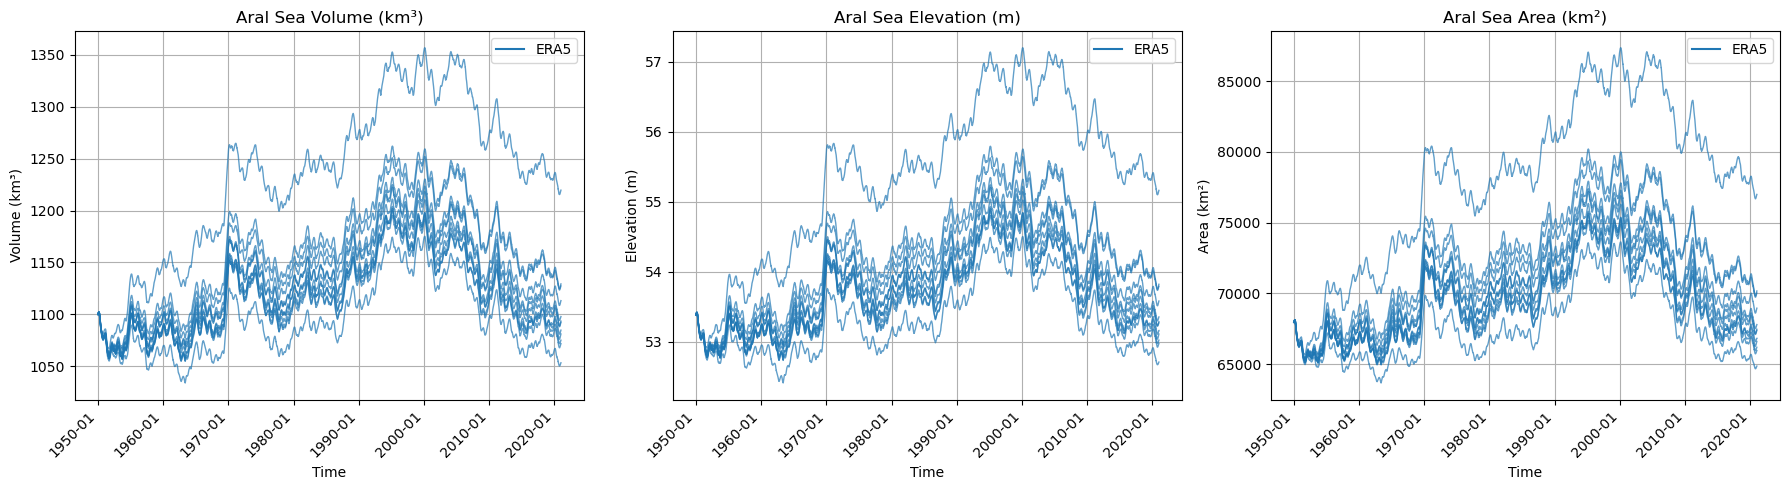

In [24]:
groups = ["ERA5"] * len(ensemble_results)

aral.plot_aral_ensemble_results(ensemble_results, groups=groups)

In [ ]:
initial_volume = 1100
ahv_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/ahv_curve.csv"
ahv_curve = pd.read_csv(ahv_file, sep=";", decimal=",")

df_aral = aral.run_connected_aral_model(
    aral_meteo,
    rivers=[River_Amu_Darya, River_Syr_Darya],
    ahv_csv=ahv_file,
    V0_km3=initial_volume,
    start_time="1950-01-01",
    end_time="2020-12-31",
)

df_aral_2 = aral.run_connected_aral_model(
    aral_meteo,
    rivers=[River_Amu_Darya_2, River_Syr_Darya_2],
    ahv_csv=ahv_file,
    V0_km3=initial_volume,
    start_time="1950-01-01",
    end_time="2020-12-31",
)

df_aral_3 = aral.run_connected_aral_model(
    aral_meteo,
    rivers=[River_Amu_Darya_3, River_Syr_Darya_3],
    ahv_csv=ahv_file,
    V0_km3=initial_volume,
    start_time="1950-01-01",
    end_time="2020-12-31",
)

In [ ]:
aral.plot_aral_results([df_aral, df_aral_2, df_aral_3])

In [ ]:
aral.plot_aral_fluxes(df_aral)

In [ ]:
River_Amu_Darya.plot_yearly()

In [ ]:
River_Syr_Darya.plot_yearly()

In [ ]:
lake = aral.LakeGeometry(ahv_file)

In [ ]:
fig, axes = lake.plot_ahv_curve()
plt.show()

In [ ]:
River_Amu_Darya_grdc.plot_yearly()

In [ ]:
River_Syr_Darya_grdc.plot_yearly()

In [ ]:
rivers_dict = {
    #'Syr Darya GRDC': River_Syr_Darya_grdc,
    #'Amu Darya GRDC': River_Amu_Darya_grdc,
    "Amu Darya Model": River_Amu_Darya,
    "Amu Darya Chatly": Amu_chatly,
    "Syr Darya Model": River_Syr_Darya,
    "Syr Darya Kazalinsk": Syr_kaza,
}

In [ ]:
multi_river = aral.MultiRiver(rivers_dict)

In [ ]:
# multi_river.plot_daily()
multi_river.plot_yearly()